In [18]:
import numpy as np 
import pandas as pd 
import json
import matplotlib.pyplot as plt 
import seaborn as sns 
from time import sleep
import requests

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from typing import Tuple, Dict, List
from tqdm import tqdm 

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [19]:
def accuracy(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    _, predictions = torch.max(y_pred, dim=1)
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

def binary_acc(y_pred: torch.Tensor, y_test: torch.Tensor) -> float:
    """
    Computes the binary accuracy of a PyTorch model given the outputs and labels.

    Parameters:
        outputs (torch.Tensor): The model outputs.
        labels (torch.Tensor): The true labels.

    Returns:
        float: The accuracy of the model.
    """
    
    predictions = torch.round(torch.sigmoid(y_pred))
    correct = torch.sum(predictions == y_test)
    accuracy = correct.float() / y_test.size(0)
    acc = torch.round(accuracy * 100)
    
    return acc

def evaluate(model: torch.nn.Module, val_set: Tuple[torch.tensor, torch.tensor], 
            criterion: torch.nn.Module, binary:bool =False) -> Tuple[torch.tensor, float, float]:
    """
    Evaluates a Pytorch model on a given dataset.
    Parameters:
    model (torch.nn.Module): The model to be evaluated
    data (tuple): A tuple containing the data and labels
    criterion (torch.nn.Module): The loss function to be used
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: False
    Returns:
    tuple: A tuple containing predicted labels, loss, and accuracy
    """
    
    X, y = val_set
    
    with torch.no_grad():
        y_pred = model(X)
    loss = criterion(y_pred, y)
    if binary:
        acc = binary_acc(y_pred, y)
    else:
        acc = accuracy(y_pred, y)
    y_pred = torch.argmax(y_pred, dim=1)

    return y_pred, loss.item(), acc.item()


def train(model: torch.nn.Module , train_loader: torch.utils.data.DataLoader, 
         val_set: Tuple[torch.Tensor, torch.Tensor], epochs: int, device: torch.device, 
         lr: float, binary: bool = True, skip: int = 1, verbose: bool = True) -> Tuple[Dict[str, List[float]], torch.Tensor]:
    """
    Trains a Pytorch model on a given training data.

    Parameters:
    model (torch.nn.Module): The model to be trained
    train_loader (DataLoader): The training data in the form of a Pytorch DataLoader
    val_set (tuple): A tuple containing the validation data and labels
    epochs (int): The number of times the training data should be passed through the model
    device (str or torch.device): The device on which to perform the computations (e.g. 'cpu' or 'cuda')
    lr (float): The learning rate for the optimizer
    binary (bool): Boolean indicating whether the task is binary classification or not. Default: True
    skip (int): The number of epochs after which the training and validation results will be printed. Default: 1

    Returns:
    tuple: A tuple containing the training history and the predicted labels after training
    """

    if binary:
        criterion = nn.BCEWithLogitsLoss()
    else:
        #criterion = nn.CrossEntropyLoss(weight=class_weights)
        criterion = nn.CrossEntropyLoss()


    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    #optimizer = torch.optim.Adam(model.parameters(), lr=lr)


    history = {'acc_train' : [], 'loss_train': [], 'acc_val': [], 'loss_val': []}
   

    for e in tqdm(range(1, epochs+1)):
        y_hat_list = []
        y_hat = np.array([])

        train_epoch_loss = 0
        train_epoch_acc = 0
        model.train()
        for X_train_batch, y_train_batch in train_loader:
            X, y = X_train_batch.to(device), y_train_batch.to(device)
            optimizer.zero_grad()
            
            y_pred = model(X)
            
            loss = criterion(y_pred, y)
            if binary:
                acc = binary_acc(y_pred,y)
            else:
                acc = accuracy(y_pred, y)
            
            loss.backward()
            optimizer.step()
            
            train_epoch_loss += loss.item()
            train_epoch_acc += acc.item()

            y_p = torch.argmax(y_pred, dim=1)
            y_hat_list.append(y_p.cpu())

        y_hat = torch.cat(y_hat_list).numpy()

        model.eval()
        _, val_loss, val_acc = evaluate(model, val_set, criterion, binary=binary)

        history['acc_train'].append(train_epoch_acc/len(train_loader))
        history['loss_train'].append(train_epoch_loss/len(train_loader))
        history['acc_val'].append(val_acc)
        history['loss_val'].append(val_loss)

        if verbose:
            if e%skip == 0:
                print(f'Epoch {e+0:03}: | Train Loss: {train_epoch_loss/len(train_loader):.3f} | Val Loss: {val_loss:.4f} | Train Acc: {train_epoch_acc/len(train_loader):.4f}| Val Acc: {val_acc:.4f}')
    return history, y_hat

class NeuralNetwork(torch.nn.Module):
  '''
  Objeto criado para facilitar o desenvolvimento dos scripts das aulas práticas.
  Opção alternativa à criação externa fdo modelo. Basicamente serve como um 
  'agregador'  de trechos comuns para a criação do modelo. Por exemplo, ao invés
  de gastar n+1 linhas para a criação de um modelo com n camadas, podemos criar 
  o mesmo modelo com apenas uma linha.
  
  Parâmetros de entrada: 
  - hidden_neurons: Lista com a quantidade de neurônios na camada escondida. 
  - hidden_activation: Função de ativação para cada camada escondida. Aceita 
  como parâmetro string ou lista. Caso o parâmetro receba string, então a mesma
  função de ativação é utilizada para todas as camadas escondidas. Caso seja uma 
  lista, cada camada terá sua propria função de ativação definida pela lista.
  - output_activation: Função de ativação para a camada de saída.
  - lr: Taxa de aprendizado
  - n_input: Tamanho do vetor de entrada.
  - n_output: Saída do modelo.
  '''
  def __init__(self,hidden_neurons = 4, hidden_activation = 'relu', n_input = 1, n_output = 1):
    super(NeuralNetwork, self).__init__()

    self.activations = {'relu': nn.ReLU(), 'sigmoid':nn.Sigmoid(), 'softmax':nn.Softmax()}

    self.fc1 = nn.Linear(n_input, hidden_neurons)
    self.ha = self.activations[hidden_activation]
    self.fc2 = nn.Linear(hidden_neurons, n_output)

  def forward(self,x):
    h = self.fc1(x)
    h1 = self.ha(h) 
    y = self.fc2(h1) 
    return y

  def predict(self, x, binary=True):
    y_hat = self.forward(x)

    if binary:
      y_pred = torch.round(torch.sigmoid(y_hat))
      y_pred = y_pred.detach().numpy()
    else:
      y_pred = torch.argmax(y_hat, dim=1)

    return y_pred
  
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / np.sum(cm).astype('float')
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

def plot_history(history):
    fig = plt.figure(figsize=(12, 4))
    gs = gridspec.GridSpec(1, 2, figure=fig)

    # Loss plot
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(history['loss_train'], label='Train Loss', color='steelblue', linewidth=2)
    ax1.plot(history['loss_val'],   label='Val Loss',   color='tomato',    linewidth=2, linestyle='--')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(history['acc_train'], label='Train Acc', color='steelblue', linewidth=2)
    ax2.plot(history['acc_val'],   label='Val Acc',   color='tomato',    linewidth=2, linestyle='--')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Training History', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

class CustomDataset(Dataset):
    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data
        
    def __getitem__(self, index):
        X_batch = torch.from_numpy(self.X_data[index]).float()
        y_batch = torch.tensor(self.y_data[index]).long()
        return X_batch, y_batch
        
    def __len__ (self):
        return len(self.X_data)

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {device}')

Using device: cpu


In [24]:
dataset = pd.read_csv("/home/wenis/Mestrado/2026.1/Dev_NN_DS/data_flights/csv/f61b4331-56ed-4f37-bb65-de513cc94d61.csv")

dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5139 entries, 0 to 5138
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp_s                      5139 non-null   float64
 1   actuator_motors.control.00       5139 non-null   float64
 2   actuator_motors.control.01       5139 non-null   float64
 3   actuator_motors.control.02       5139 non-null   float64
 4   actuator_motors.control.03       5139 non-null   float64
 5   vehicle_angular_velocity.xyz.00  5139 non-null   float64
 6   vehicle_angular_velocity.xyz.01  5139 non-null   float64
 7   vehicle_angular_velocity.xyz.02  5139 non-null   float64
 8   vehicle_attitude.q.00            5139 non-null   float64
 9   vehicle_attitude.q.01            5139 non-null   float64
 10  vehicle_attitude.q.02            5139 non-null   float64
 11  vehicle_attitude.q.03            5139 non-null   float64
 12  vehicle_local_positi

In [25]:
dataset.describe()

,timestamp_s,actuator_motors.control.00,actuator_motors.control.01,actuator_motors.control.02,actuator_motors.control.03,vehicle_angular_velocity.xyz.00,vehicle_angular_velocity.xyz.01,vehicle_angular_velocity.xyz.02,vehicle_attitude.q.00,vehicle_attitude.q.01,vehicle_attitude.q.02,vehicle_attitude.q.03,vehicle_local_position.ax,vehicle_local_position.ay,vehicle_local_position.az,vehicle_local_position.vx,vehicle_local_position.vy,vehicle_local_position.vz
count,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000,5139.000000
mean,115.806121,0.386821,0.383276,0.470112,0.434557,-0.000243,0.000134,0.007520,0.145451,0.010013,0.014200,0.986715,0.087526,-0.108830,0.016309,-0.100334,-0.001940,0.049963
std,16.484887,0.129240,0.138549,0.154483,0.152171,0.119256,0.109026,0.041906,0.057037,0.027753,0.026898,0.013678,1.706014,2.161179,1.565186,0.830613,0.582266,1.605227
min,87.314249,0.002000,0.000000,0.002000,0.000000,-0.914311,-0.793701,-0.074461,0.109248,-0.073180,-0.069218,0.937590,-6.506943,-6.351576,-7.593383,-2.886542,-2.756538,-3.795256
25%,101.523917,0.361500,0.372036,0.463374,0.422977,-0.026763,-0.027942,-0.011058,0.122017,-0.002553,0.006257,0.990695,-0.996807,-1.342453,-0.869054,-0.081625,-0.020876,-0.802587
50%,115.820589,0.415710,0.411356,0.511756,0.468190,0.000027,0.000391,0.000207,0.127079,0.006546,0.011278,0.991463,0.002521,0.007810,-0.019855,-0.002410,0.017102,0.255030
75%,130.078713,0.451037,0.456187,0.543893,0.504666,0.030055,0.031706,0.013739,0.131778,0.020017,0.016132,0.992063,1.072459,1.126172,0.912114,0.084790,0.085251,1.274768
max,144.343449,0.627047,0.621655,0.712102,0.704573,0.593024,0.410500,0.356331,0.328713,0.120594,0.141582,0.993917,5.478286,7.671557,5.126872,2.020674,0.913125,1.978985


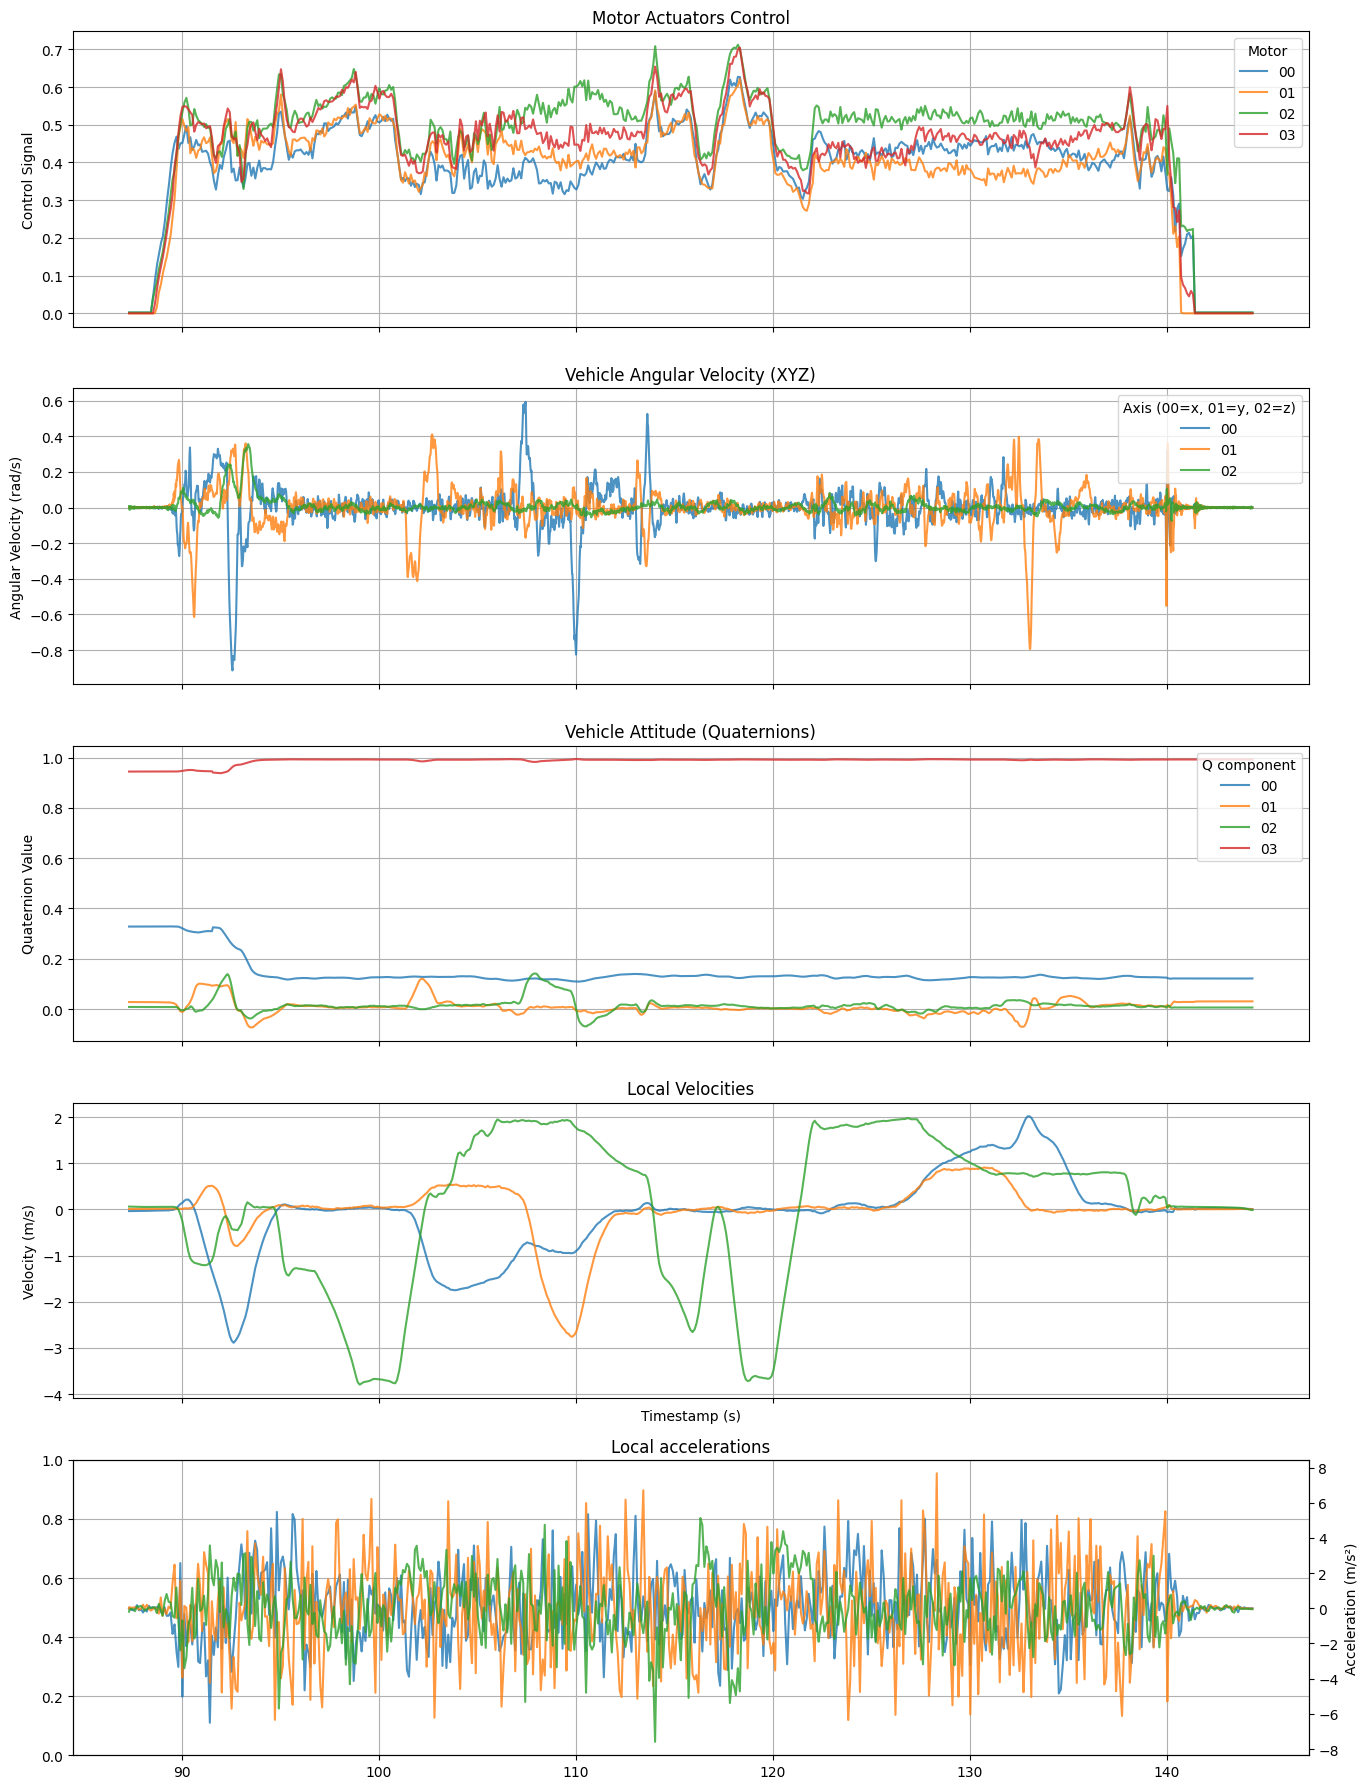

In [26]:
import matplotlib.pyplot as plt

# Create a figure with 5 subplots sharing the x-axis
fig, axs = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

# Convert timestamp to a numpy array once to reuse it
t_vals = dataset['timestamp_s'].to_numpy()

# ---------------------------------------------------------
# 1. Motor Actuators Control
# ---------------------------------------------------------
motors = ['actuator_motors.control.00', 'actuator_motors.control.01', 
          'actuator_motors.control.02', 'actuator_motors.control.03']

for m in motors:
    # Adding .to_numpy() to the y-axis data
    axs[0].plot(t_vals, dataset[m].to_numpy(), label=m[-2:], alpha=0.8)

axs[0].set_title('Motor Actuators Control')
axs[0].set_ylabel('Control Signal')
axs[0].legend(loc='upper right', title="Motor")
axs[0].grid(True)

# ---------------------------------------------------------
# 2. Vehicle Angular Velocity
# ---------------------------------------------------------
ang_vels = ['vehicle_angular_velocity.xyz.00', 'vehicle_angular_velocity.xyz.01', 
            'vehicle_angular_velocity.xyz.02']

for av in ang_vels:
    axs[1].plot(t_vals, dataset[av].to_numpy(), label=av[-2:], alpha=0.8)

axs[1].set_title('Vehicle Angular Velocity (XYZ)')
axs[1].set_ylabel('Angular Velocity (rad/s)')
axs[1].legend(loc='upper right', title="Axis (00=x, 01=y, 02=z)")
axs[1].grid(True)

# ---------------------------------------------------------
# 3. Vehicle Attitude (Quaternions)
# ---------------------------------------------------------
attitude = ['vehicle_attitude.q.00', 'vehicle_attitude.q.01', 
            'vehicle_attitude.q.02', 'vehicle_attitude.q.03']

for q in attitude:
    axs[2].plot(t_vals, dataset[q].to_numpy(), label=q[-2:], alpha=0.8)

axs[2].set_title('Vehicle Attitude (Quaternions)')
axs[2].set_ylabel('Quaternion Value')
axs[2].legend(loc='upper right', title="Q component")
axs[2].grid(True)

# ---------------------------------------------------------
# 4. Local Accelerations and Velocities
# ---------------------------------------------------------

vels = ['vehicle_local_position.vx', 'vehicle_local_position.vy', 'vehicle_local_position.vz']

# Plot velocities on the primary (left) y-axis
for v in vels:
    axs[3].plot(t_vals, dataset[v].to_numpy(), label=f"Vel {v[-2:]}", linestyle='-', alpha=0.8)
axs[3].set_ylabel('Velocity (m/s)')
axs[3].set_xlabel('Timestamp (s)')


# Combine legends from both primary and twin axes
lines_1, labels_1 = axs[3].get_legend_handles_labels()

axs[3].set_title('Local Velocities')
axs[3].grid(True)


#### 5 accelerations
accels = ['vehicle_local_position.ax', 'vehicle_local_position.ay', 'vehicle_local_position.az']
# Create a twin y-axis to plot accelerations on the right
ax4_twin = axs[4].twinx()
for a in accels:
    ax4_twin.plot(t_vals, dataset[a].to_numpy(), label=f"Acc {a[-2:]}", linestyle='-', alpha=0.8)
ax4_twin.set_ylabel('Acceleration (m/s²)')
axs[4].set_title('Local accelerations')
axs[4].grid(True)

# ---------------------------------------------------------
# Final Layout Adjustments
# ---------------------------------------------------------
plt.tight_layout()
plt.show()